# TASK1: Sampling

In [28]:
#needed libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

## 1. Define and Visualize the Distribution 

In [29]:
mu = np.array([0, 0])
Sigma = np.array([[1, 0], 
                  [0, 1]])

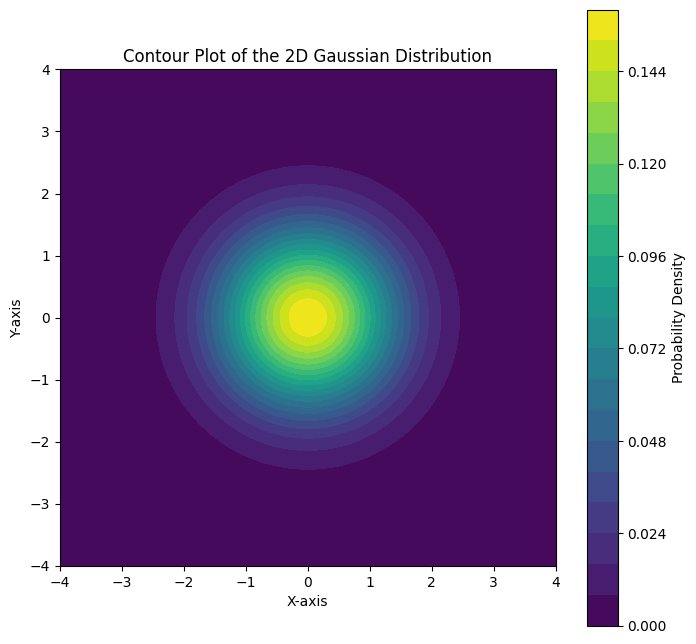

In [39]:
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)

pos = np.dstack((X, Y))

rv = multivariate_normal(mu, Sigma)
Z = rv.pdf(pos)

plt.figure(figsize=(8, 8))
plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.colorbar(label='Probability Density')
plt.title('Contour Plot of the 2D Gaussian Distribution')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

### Plot Explanation:
The plot shows the probability density of a 2D Gaussian distribution centered at (0,0). The concentric circular contours indicate that all points at the same distance from the center have the same probability density. The density is highest (lightest color) at the mean (0,0) and decreases as you move away from the center.

### 1-Why is the distribution symmetric?

The distribution is symmetric for two main reasons related to its parameters:
Mean at the Origin: The mean is μ=[0,0], placing the center of the distribution at the origin.

Identity Covariance Matrix: The covariance matrix is Σ=I

    (1   0)
    (0   1​)

This means the variance is 1 for both dimensions ( 𝜎1 = 𝜎2 = 1 ) and the covariance between them is 0. Equal variance and zero covariance result in a circular shape, which is perfectly symmetric.

### 2-What role does the covariance matrix play?
The covariance matrix Σ dictates the shape and orientation of the distribution.

Diagonal Elements (Variances): Control the spread or “width” of the distribution along each axis.

Off-Diagonal Elements (Covariances): Control the correlation between the dimensions. A non-zero covariance would stretch and rotate the distribution, turning the circular contours into ellipses.

## 2. Sampling Methods 

### reference method.

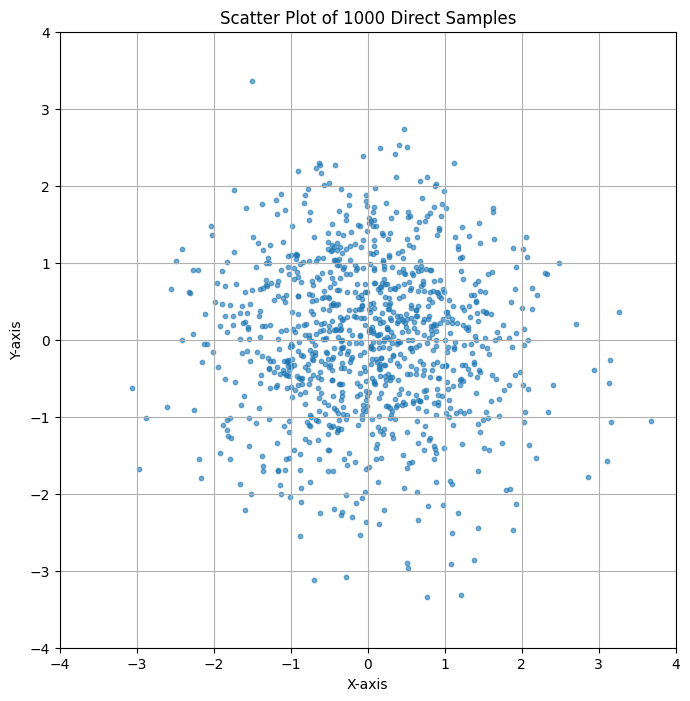

In [31]:
direct_samples = np.random.multivariate_normal(mu, Sigma, 1000)

plt.figure(figsize=(8, 8))
plt.scatter(direct_samples[:, 0], direct_samples[:, 1], alpha=0.6, s=10)
plt.title('Scatter Plot of 1000 Direct Samples')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()


### Langevin Dynamics

In [32]:
def score_function(x):
    return -x

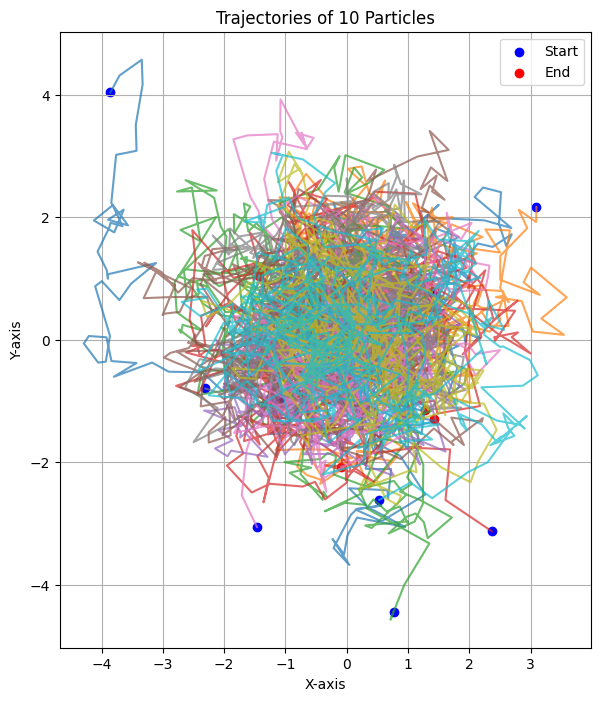

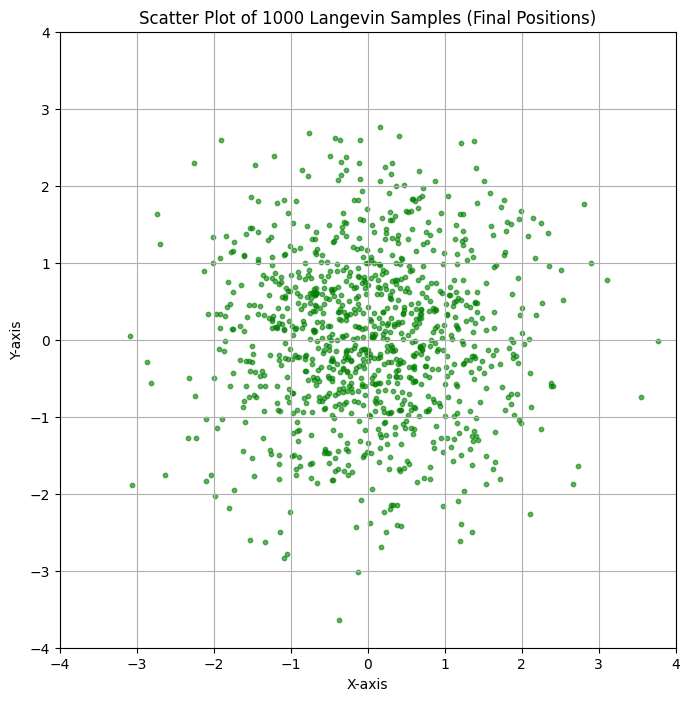

In [ ]:
num_particles = 1000
initial_positions = np.random.uniform(-5, 5, size=(num_particles, 2))
D = 2
T = 500
epsilon = 0.05

particles = np.copy(initial_positions)
history = np.zeros((T, num_particles, D))

# Store trajectories for the first 10 particles
num_trajectories_to_track = 10
trajectories = np.zeros((T + 1, num_trajectories_to_track, 2))
trajectories[0] = particles[:num_trajectories_to_track]

for t in range(T):
    history[t] = particles
    noise = np.random.normal(0, 1, size=(num_particles, 2))
    # noise = 0

    particles = particles + epsilon * score_function(particles) + np.sqrt(2 * epsilon) * noise
    trajectories[t + 1] = particles[:num_trajectories_to_track]

langevin_samples = particles

plt.figure(figsize=(8, 8))
for i in range(num_trajectories_to_track):
    plt.plot(trajectories[:, i, 0], trajectories[:, i, 1], alpha=0.7)

plt.scatter(trajectories[0, :, 0], trajectories[0, :, 1], color='blue', label='Start')
plt.scatter(trajectories[-1, :, 0], trajectories[-1, :, 1], color='red', label='End')

plt.title('Trajectories of 10 Particles')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

plt.figure(figsize=(8, 8))
plt.scatter(langevin_samples[:, 0], langevin_samples[:, 1], alpha=0.6, s=10, color='green')
plt.title('Scatter Plot of 1000 Langevin Samples (Final Positions)')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
plt.show()

#### 1- Effect of step size (𝜖):
Large 𝜖 : Particles take large steps. This can lead to faster exploration of the space, but if it’s too large, the process becomes unstable and may “overshoot” the high-density region, causing the samples to diverge.

Small 𝜖 : Particles take small, cautious steps. This is more stable and follows the true probability landscape more closely, but it requires many more iterations (T) to converge. It’s a trade-off between speed and stability.

#### 2- How many iterations for convergence?
You can determine this by plotting a summary statistic over time. A good choice is the average distance of all particles from the origin. The sampler has reached a stable distribution when this plot flattens out. We can use the following code to check this:

For epsilon=0.05, it likely stabilizes after about 50-100 iterations.

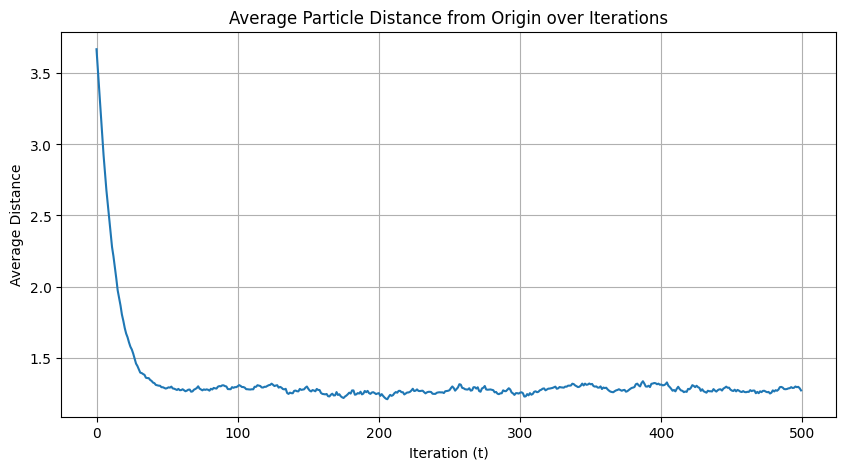

In [ ]:
T = 500
epsilon = 0.05
num_particles = 1000
initial_positions = np.random.uniform(-5, 5, size=(num_particles, 2))

avg_dist_from_origin = []
particles = np.copy(initial_positions) 

for t in range(T):
    noise = np.random.normal(0, 1, size=(num_particles, 2))
    particles = particles + epsilon * score_function(particles) + np.sqrt(2 * epsilon) * noise
    
    # Calculate and store the average distance of all particles from the origin
    avg_dist = np.mean(np.linalg.norm(particles, axis=1))
    avg_dist_from_origin.append(avg_dist)

plt.figure(figsize=(10, 5))
plt.plot(avg_dist_from_origin)
plt.title('Average Particle Distance from Origin over Iterations')
plt.xlabel('Iteration (t)')
plt.ylabel('Average Distance')
plt.grid(True)
plt.show()


#### 3- Why do more samples appear near the origin?
The target distribution is a Gaussian centered at the origin, which is the region of highest probability density. Both sampling methods are designed to generate samples representative of this distribution. Therefore, more samples will naturally be generated in or move towards the area where the probability is highest.

#### 4- What if you remove the noise term?
The update rule would become: 

#### 𝑥𝑡 + 1 = 𝑥𝑡 + 𝜖𝑠(𝑥𝑡) = 𝑥𝑡 − 𝜖𝑥𝑡 = (1−𝜖)𝑥𝑡 

This is no longer a sampling algorithm. It is gradient ascent on the log-probability. All particles would move deterministically along the gradient towards the point of maximum probability (the mode), which is the origin (0,0). They would all collapse to a single point at the origin instead of exploring the distribution.

#### 5- Do all trajectories converge to similar regions?
Yes. The trajectory plot shows that particles starting from various random locations all move towards the central, high-density region around the origin. This indicates that the sampler is working correctly and is not getting stuck, exploring the space as dictated by the target distribution.

## 3. Inference from Samples 

## Estimate statistical quantities

In [ ]:
true_mean = 0.0
true_variance = 1.0

# axis=0 calculates the mean for each column (dimension) separately
mean_direct = np.mean(direct_samples, axis=0)
var_direct = np.var(direct_samples, axis=0)

mean_langevin = np.mean(langevin_samples, axis=0)
var_langevin = np.var(langevin_samples, axis=0)


print("--- Comparison of Estimated Statistics ---")
print(f"True Mean: {true_mean:.4f} | True Variance: {true_variance:.4f}")
print("-" * 40)

print("\nDirect Sampling:")
print(f"  Estimated Mean (dim 1, dim 2): {mean_direct[0]:.4f}, {mean_direct[1]:.4f}")
print(f"  Estimated Variance (dim 1, dim 2): {var_direct[0]:.4f}, {var_direct[1]:.4f}")

print("\nLangevin Sampling:")
print(f"  Estimated Mean (dim 1, dim 2): {mean_langevin[0]:.4f}, {mean_langevin[1]:.4f}")
print(f"  Estimated Variance (dim 1, dim 2): {var_langevin[0]:.4f}, {var_langevin[1]:.4f}")


--- Comparison of Estimated Statistics ---
True Mean: 0.0000 | True Variance: 1.0000
----------------------------------------

Direct Sampling:
  Estimated Mean (dim 1, dim 2): 0.0081, 0.0281
  Estimated Variance (dim 1, dim 2): 0.9603, 1.0625

Langevin Sampling:
  Estimated Mean (dim 1, dim 2): -0.0227, 0.0219
  Estimated Variance (dim 1, dim 2): 1.0044, 0.9898


### 1. Why can the Langevin estimates still be biased even when the final samples come from independent chains?

The bias in Langevin sampling comes from the discretization of a continuous process.

The theoretical Langevin Dynamics is a continuous-time process that guarantees convergence to the exact target distribution,𝑝(𝑥).
However, in our algorithm, we cannot simulate a continuous process. We approximate it with discrete time steps using the update rule.
This update is an Euler-Maruyama approximation. This approximation introduces a systematic error, or bias. The distribution that our discrete chain actually samples from, let’s call it 𝑞(𝑥), is not identical to the true target 𝑝(𝑥). It is an approximation whose accuracy depends on the step size 𝜖.
Therefore, even if you run many independent chains and take the final sample from each, every one of those samples is drawn from the approximate distribution 𝑞(𝑥), not the true distribution p(x). Any statistics (like the mean or variance) calculated from these samples will be estimates for q(x), and thus will be biased estimates for the statistics of p(x). The bias gets smaller as 𝜖 → 0, but it never truly disappears for a finite step size.

### 2. How do the number of iterations T and the step size ε affect the accuracy of the Langevin samples?

T and ε control a crucial trade-off between convergence and bias.

Number of Iterations T (Affects Convergence): T determines how long the simulation runs. The initial samples are drawn from an Uniform distribution and are not representative of the target distribution. The chain needs to run for a sufficient number of steps to “forget” its starting point and converge to its stationary distribution. This initial period is often called “burn-in”.

If T is too small: The chain has not converged. The samples will still be heavily influenced by the initial state, leading to inaccurate and biased estimates.

If T is large enough: The samples will be drawn from the chain’s stationary distribution, which is a good approximation of the target, thus improving accuracy.

Step Size ε (Affects Bias and Speed): The step size ε is the most critical parameter.

Accuracy (Bias): As explained above, ε controls the discretization bias. A smaller ε results in a more accurate approximation of the continuous process. This means the stationary distribution of the chain is closer to the true target distribution, leading to lower bias and more accurate samples.

Convergence Speed: A smaller ε also means the particle takes smaller steps at each iteration. This slows down the exploration of the probability space, meaning a larger T is required to reach convergence. Conversely, a larger ε moves the particles faster, but at the cost of higher bias.

Stability: If ε is too large, the updates can overshoot the high-probability regions entirely, causing the simulation to become unstable and diverge (leading to NaN or infinite values).

In summary: There is a trade-off. You need T to be large enough for the simulation to converge. You need ε to be small enough to keep the bias low, but large enough for the chain to converge efficiently within T steps without going unstable.

## 4. Compare the Sampling Methods

### Quantitative Comparison

In [ ]:
true_mean = 0.0
true_variance = 1.0

mean_direct = np.mean(direct_samples, axis=0)
var_direct = np.var(direct_samples, axis=0)
mean_langevin = np.mean(langevin_samples, axis=0)
var_langevin = np.var(langevin_samples, axis=0)

error_mean_direct = np.abs(mean_direct - true_mean)
error_var_direct = np.abs(var_direct - true_variance)
error_mean_langevin = np.abs(mean_langevin - true_mean)
error_var_langevin = np.abs(var_langevin - true_variance)

print("--- Quantitative Comparison of Sampling Methods ---")
print(f"{'Method':<12} | {'Stat':<15} | {'Dim 1':<10} | {'Dim 2':<10}")
print("-" * 55)

print(f"{'Direct':<12} | {'Est. Mean':<15} | {mean_direct[0]:<10.4f} | {mean_direct[1]:<10.4f}")
print(f"{'':<12} | {'Mean Abs Error':<15} | {error_mean_direct[0]:<10.4f} | {error_mean_direct[1]:<10.4f}")
print(f"{'':<12} | {'Est. Variance':<15} | {var_direct[0]:<10.4f} | {var_direct[1]:<10.4f}")
print(f"{'':<12} | {'Var Abs Error':<15} | {error_var_direct[0]:<10.4f} | {error_var_direct[1]:<10.4f}")
print("-" * 55)

print(f"{'Langevin':<12} | {'Est. Mean':<15} | {mean_langevin[0]:<10.4f} | {mean_langevin[1]:<10.4f}")
print(f"{'':<12} | {'Mean Abs Error':<15} | {error_mean_langevin[0]:<10.4f} | {error_mean_langevin[1]:<10.4f}")
print(f"{'':<12} | {'Est. Variance':<15} | {var_langevin[0]:<10.4f} | {var_langevin[1]:<10.4f}")
print(f"{'':<12} | {'Var Abs Error':<15} | {error_var_langevin[0]:<10.4f} | {error_var_langevin[1]:<10.4f}")


--- Quantitative Comparison of Sampling Methods ---
Method       | Stat            | Dim 1      | Dim 2     
-------------------------------------------------------
Direct       | Est. Mean       | 0.0081     | 0.0281    
             | Mean Abs Error  | 0.0081     | 0.0281    
             | Est. Variance   | 0.9603     | 1.0625    
             | Var Abs Error   | 0.0397     | 0.0625    
-------------------------------------------------------
Langevin     | Est. Mean       | -0.0227    | 0.0219    
             | Mean Abs Error  | 0.0227     | 0.0219    
             | Est. Variance   | 1.0044     | 0.9898    
             | Var Abs Error   | 0.0044     | 0.0102    


#### Discussion on which method better matches: 
Direct sampling is expected to better match the target distribution. It is an exact method that draws independent samples directly from the true distribution p(x). Its error is purely due to finite sample size (sampling error).

Langevin Dynamics is an approximate method (MCMC) that suffers from both finite sample size error and systematic bias from the discretization of the continuous process. Therefore, direct sampling will almost always yield more accurate estimates.

#### Why Langevin performs worse:
If Langevin sampling shows higher errors, it’s due to a combination of factors inherent to the method:

Discretization Bias: The primary reason. Our use of a finite step size ϵ>0 means we are sampling from an approximation q(x) of the true distribution p(x), which introduces systematic error.

Insufficient Iterations / Lack of Convergence: If T is not large enough, the samples are taken before the Markov chain has reached its stationary distribution. They will be biased towards the initial starting positions (the uniform distribution in our case), not the target Gaussian. This increases error.

Poor Step Size: If 𝜖 is too large, the discretization bias is high. If it’s too small, the chain explores the space very slowly, and a much larger T would be needed to achieve convergence.

### Langevin Sampler Convergence Analysis

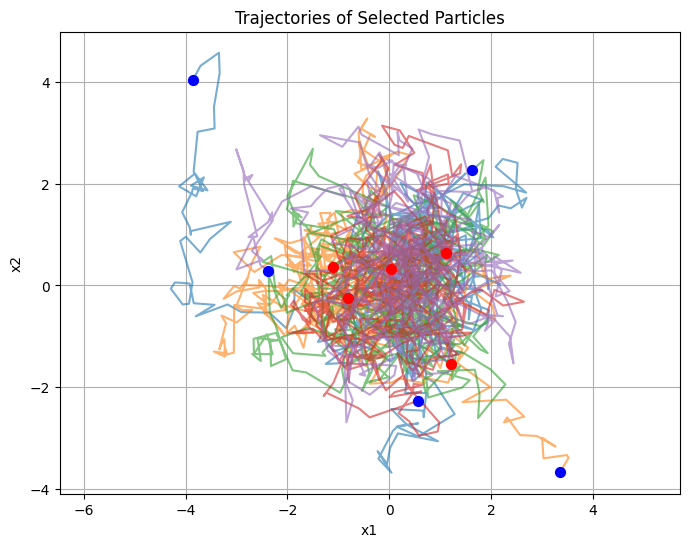

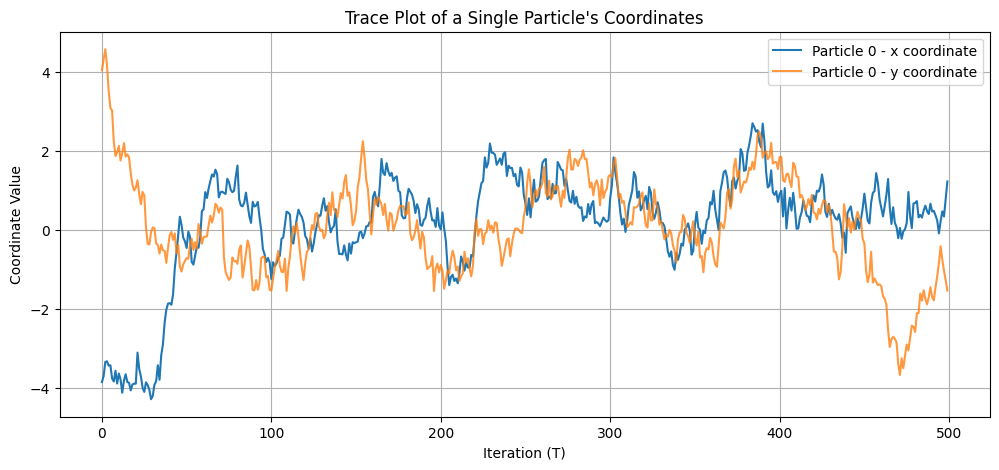

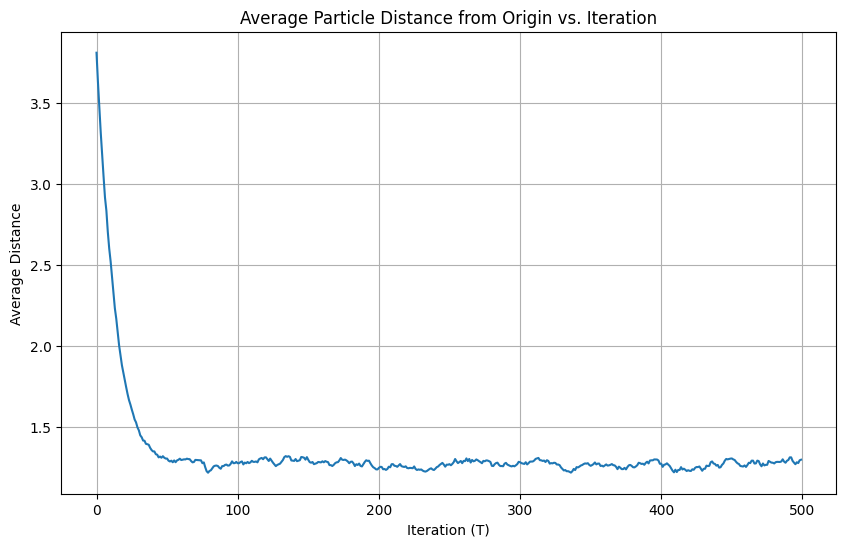

In [37]:
plt.figure(figsize=(8, 6))
particle_indices_to_plot = [0, 100, 200, 300, 400]
for i in particle_indices_to_plot:
    plt.plot(history[:, i, 0], history[:, i, 1], alpha=0.6)
    plt.scatter(history[0, i, 0], history[0, i, 1], c='blue', s=50, zorder=3)
    plt.scatter(history[-1, i, 0], history[-1, i, 1], c='red', s=50, zorder=3)
plt.title('Trajectories of Selected Particles')
plt.xlabel('x1')
plt.ylabel('x2')
plt.grid(True)
plt.axis('equal')
plt.show()


plt.figure(figsize=(12, 5))
particle_to_trace = 0
plt.plot(history[:, particle_to_trace, 0], label=f'Particle {particle_to_trace} - x coordinate')
plt.plot(history[:, particle_to_trace, 1], label=f'Particle {particle_to_trace} - y coordinate', alpha=0.8)
plt.title('Trace Plot of a Single Particle\'s Coordinates')
plt.xlabel('Iteration (T)')
plt.ylabel('Coordinate Value')
plt.legend()
plt.grid(True)
plt.show()

# np.sum(history**2, axis=2) sums the squares of the coordinates -> (T, N)
distances_from_origin = np.sqrt(np.sum(history**2, axis=2))

average_distance = np.mean(distances_from_origin, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(average_distance)
plt.title('Average Particle Distance from Origin vs. Iteration')
plt.xlabel('Iteration (T)')
plt.ylabel('Average Distance')
plt.grid(True)
plt.show()


#### 1- Do particles move toward the high-density region?
Yes. The trajectory plot clearly shows that particles, regardless of their random starting position in the [-5, 5] box, are quickly pulled toward the origin [0, 0], which is the mode (highest density point) of the target Gaussian distribution.

#### 2- After how many iterations do trajectories appear stable?
Look at the “Average Particle Distance from Origin” plot. You will see a sharp drop in the beginning, followed by the curve flattening out into a noisy but stable plateau. The point where the curve flattens indicates when the system has reached its stationary distribution. In this example, it appears to stabilize after approximately 50-100 iterations. After this point, the average properties of the particle ensemble remain roughly constant.

### Visual Comparison of Distributions

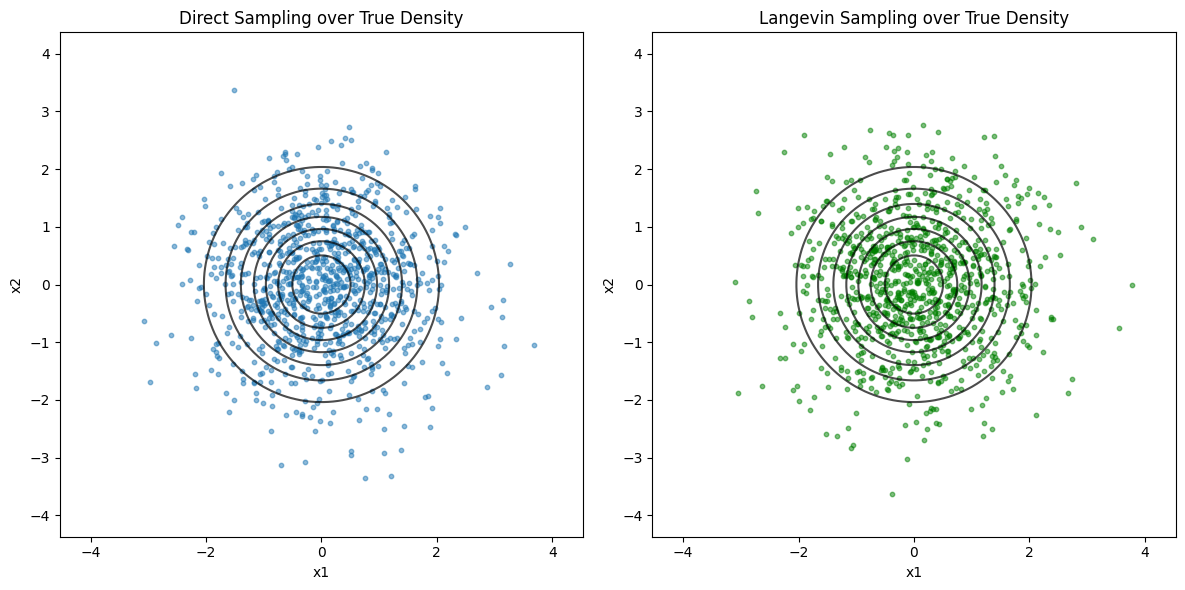

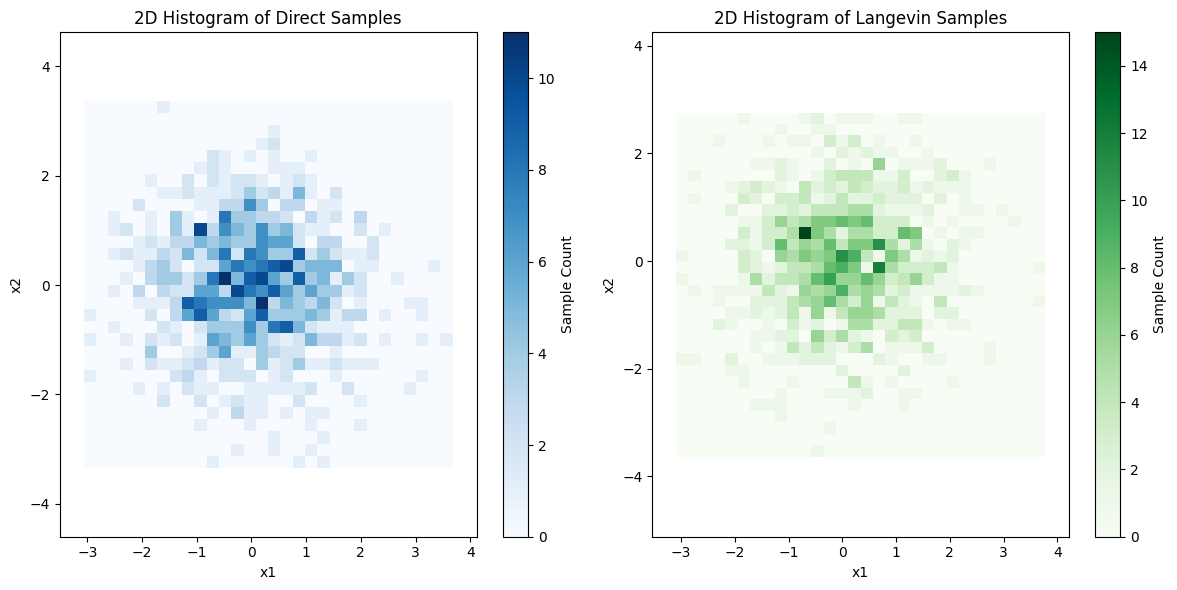

In [ ]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.contour(X, Y, Z, colors='black', alpha=0.7)
plt.scatter(direct_samples[:, 0], direct_samples[:, 1], alpha=0.5, s=10)
plt.title('Direct Sampling over True Density')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.contour(X, Y, Z, colors='black', alpha=0.7)
plt.scatter(langevin_samples[:, 0], langevin_samples[:, 1], alpha=0.5, s=10, c='green')
plt.title('Langevin Sampling over True Density')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist2d(direct_samples[:, 0], direct_samples[:, 1], bins=30, cmap='Blues')
plt.colorbar(label='Sample Count')
plt.title('2D Histogram of Direct Samples')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')

plt.subplot(1, 2, 2)
plt.hist2d(langevin_samples[:, 0], langevin_samples[:, 1], bins=30, cmap='Greens')
plt.colorbar(label='Sample Count')
plt.title('2D Histogram of Langevin Samples')
plt.xlabel('x1')
plt.ylabel('x2')
plt.axis('equal')

plt.tight_layout()
plt.show()
